# Hey Banco — Datathon 2026
## Tarea 1: EDA Transacciones

Análisis exploratorio profundo de `hey_transacciones.csv` (802,384 registros).

| Sección | Contenido |
|---------|----------|
| 1 | Setup y carga |
| 2 | Volumen por `tipo_operacion` y `estatus` — tasa de rechazo |
| 3 | Top 10 categorías MCC por monto total |
| 4 | Distribución de `motivo_no_procesada` |
| 5 | Heatmap temporal `hora_del_dia` × `dia_semana` |
| 6 | Señales de riesgo: `es_internacional` y `patron_uso_atipico` |
| 7 | Cashback (usuarios Hey Pro) |
| 8 | Top canales por volumen |
| 9 | Análisis de reintentos (`intento_numero > 1`) |

## 1. Setup y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_colwidth', 60)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
FIGSIZE_WIDE = (14, 5)
FIGSIZE_SQ   = (10, 7)

BASE = Path(r"Datathon_Hey_2026_dataset_transacciones 1/dataset_transacciones")

# ── Transacciones ─────────────────────────────────────────────────────────────
df_tx = pd.read_csv(
    BASE / "hey_transacciones.csv",
    dtype={
        "transaccion_id": str, "user_id": str, "producto_id": str,
        "tipo_operacion": str, "canal": str, "categoria_mcc": str,
        "ciudad_transaccion": str, "estatus": str, "motivo_no_procesada": str,
        "dia_semana": str, "dispositivo": str,
    },
    parse_dates=["fecha_hora"],
)
if "es_dato_sintetico" in df_tx.columns:
    df_tx = df_tx.drop(columns=["es_dato_sintetico"])

# ── Clientes (para saber si es Hey Pro) ───────────────────────────────────────
df_cli = pd.read_csv(
    BASE / "hey_clientes.csv",
    dtype={"user_id": str},
    usecols=["user_id", "es_hey_pro"],
)

# Merge ligero para flag Hey Pro en transacciones
df_tx = df_tx.merge(df_cli, on="user_id", how="left")

print(f"Transacciones cargadas: {len(df_tx):,} filas × {df_tx.shape[1]} columnas")
print(f"Período: {df_tx['fecha_hora'].min().date()} → {df_tx['fecha_hora'].max().date()}")
df_tx.head(3)

Transacciones cargadas: 802,384 filas × 22 columnas
Período: 2025-01-01 → 2025-12-15


,transaccion_id,user_id,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,estatus,motivo_no_procesada,intento_numero,meses_diferidos,cashback_generado,descripcion_libre,hora_del_dia,dia_semana,es_internacional,dispositivo,patron_uso_atipico,es_hey_pro
0,TXN-0000000055,USR-00001,PRD-00000002,2025-01-15 14:17:42,compra,app_ios,33.88,DivertidoPark,entretenimiento,"Nueva York, NY",completada,NaN,1,NaN,0.34,Cargo automático,14,Wednesday,True,app_ios,False,True
1,TXN-0000000048,USR-00001,PRD-00000001,2025-01-17 00:31:56,cargo_recurrente,app_ios,249.00,GamerPass,servicios_digitales,CDMX - Benito Juárez,completada,NaN,1,NaN,NaN,Cargo automático,0,Friday,False,app_ios,False,True
2,TXN-0000000018,USR-00001,PRD-00000001,2025-01-17 22:48:23,cargo_recurrente,app_huawei,399.00,CloudDrive MX,servicios_digitales,CDMX - Benito Juárez,completada,NaN,1,NaN,NaN,inv hey,22,Friday,False,app_huawei,False,True


## 2. Volumen por `tipo_operacion` y `estatus` — Tasa de rechazo global

In [2]:
# ── KPIs globales ─────────────────────────────────────────────────────────────
total          = len(df_tx)
estatus_dist   = df_tx["estatus"].value_counts()
estatus_pct    = df_tx["estatus"].value_counts(normalize=True).mul(100)

tasa_rechazo   = estatus_pct.get("no_procesada", 0)
tasa_disputa   = estatus_pct.get("en_disputa", 0)
tasa_revertida = estatus_pct.get("revertida", 0)

print("=" * 55)
print(f"  TOTAL TRANSACCIONES          : {total:>10,}")
print("=" * 55)
for est, cnt in estatus_dist.items():
    print(f"  {est:<30}: {cnt:>8,}  ({estatus_pct[est]:5.2f}%)")
print("-" * 55)
print(f"  ► TASA DE RECHAZO GLOBAL     : {tasa_rechazo:>8.2f}%")
print(f"  ► Tasa en disputa            : {tasa_disputa:>8.2f}%")
print(f"  ► Tasa revertida             : {tasa_revertida:>8.2f}%")

  TOTAL TRANSACCIONES          :    802,384
  completada                    :  748,267  (93.26%)
  no_procesada                  :   26,609  ( 3.32%)
  en_disputa                    :   19,033  ( 2.37%)
  revertida                     :    8,475  ( 1.06%)
-------------------------------------------------------
  ► TASA DE RECHAZO GLOBAL     :     3.32%
  ► Tasa en disputa            :     2.37%
  ► Tasa revertida             :     1.06%


estatus,completada,en_disputa,no_procesada,revertida,TOTAL,pct_rechazo
tipo_operacion,,,,,,
compra,298338,7511,10321,3354,319524,3.23
transf_entrada,85975,2275,2879,1038,92167,3.12
transf_salida,84097,2176,2850,993,90116,3.16
cargo_recurrente,62750,1607,2205,687,67249,3.28
pago_credito,47534,1199,2415,503,51651,4.68
pago_servicio,45329,1148,1576,509,48562,3.25
abono_inversion,39343,1003,1029,394,41769,2.46
retiro_cajero,36196,910,1475,408,38989,3.78
deposito_oxxo,21464,530,896,262,23152,3.87


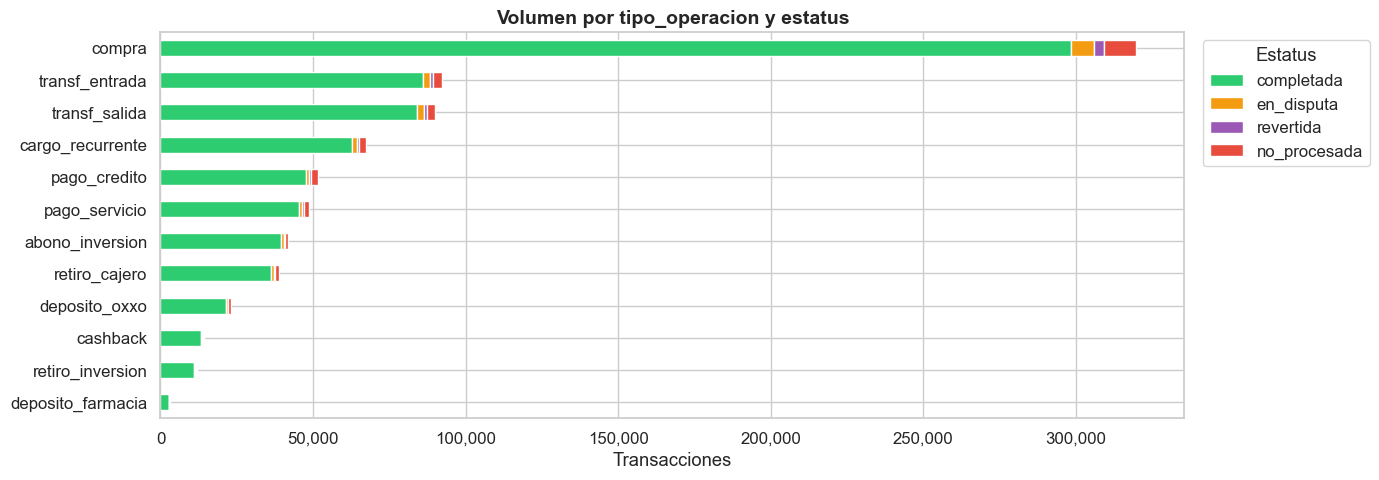

In [3]:
# ── Tabla cruzada tipo_operacion × estatus ────────────────────────────────────
pivot = (
    df_tx.groupby(["tipo_operacion", "estatus"])
    .size()
    .unstack(fill_value=0)
)
pivot["TOTAL"]         = pivot.sum(axis=1)
pivot["pct_rechazo"]   = (pivot.get("no_procesada", 0) / pivot["TOTAL"] * 100).round(2)
pivot = pivot.sort_values("TOTAL", ascending=False)

display(pivot)

# ── Gráfico barras apiladas ───────────────────────────────────────────────────
orden_est = ["completada", "en_disputa", "revertida", "no_procesada"]
cols_plot = [c for c in orden_est if c in pivot.columns]

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
pivot[cols_plot].sort_values("completada" if "completada" in cols_plot else cols_plot[0]).plot(
    kind="barh", stacked=True, ax=ax,
    color=["#2ecc71", "#f39c12", "#9b59b6", "#e74c3c"],
)
ax.set_title("Volumen por tipo_operacion y estatus", fontsize=14, fontweight="bold")
ax.set_xlabel("Transacciones")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title="Estatus", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 3. Top 10 categorías MCC por monto total

,monto_total,n_txn,monto_promedio
categoria_mcc,,,
transferencia,"$3,972,634,055","341,850","$11,620.99"
gobierno,"$117,610,533","57,282","$2,053.18"
supermercado,"$109,560,908","58,762","$1,864.49"
restaurante,"$77,469,683","70,278","$1,102.33"
servicios_digitales,"$50,204,569","86,525",$580.23
hogar,"$47,238,685","7,845","$6,021.50"
transporte,"$45,848,476","15,522","$2,953.77"
tecnologia,"$37,945,070","16,069","$2,361.38"
viajes,"$37,490,585","12,051","$3,110.99"


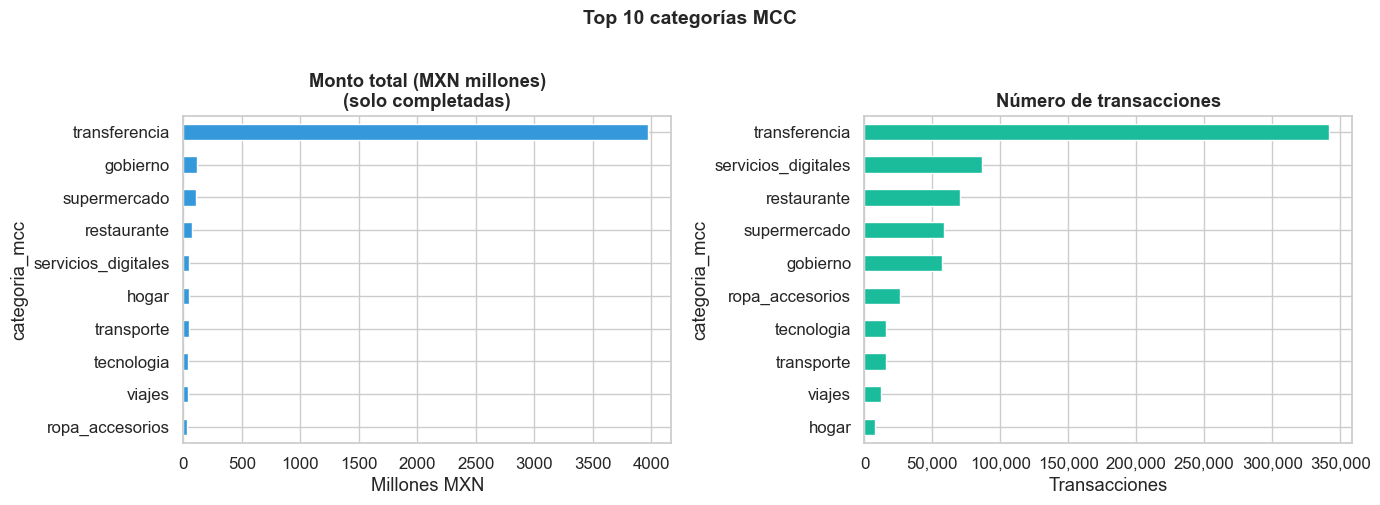

In [4]:
top_mcc = (
    df_tx[df_tx["estatus"] == "completada"]
    .groupby("categoria_mcc")["monto"]
    .agg(monto_total="sum", n_txn="count", monto_promedio="mean")
    .sort_values("monto_total", ascending=False)
    .head(10)
)
top_mcc["monto_total_M"] = top_mcc["monto_total"] / 1e6

display(
    top_mcc[["monto_total", "n_txn", "monto_promedio"]]
    .style.format({"monto_total": "${:,.0f}", "n_txn": "{:,}", "monto_promedio": "${:,.2f}"})
    .bar(subset=["monto_total"], color="#3498db")
)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

top_mcc["monto_total_M"].sort_values().plot(
    kind="barh", ax=axes[0], color="#3498db"
)
axes[0].set_title("Monto total (MXN millones)\n(solo completadas)", fontweight="bold")
axes[0].set_xlabel("Millones MXN")

top_mcc["n_txn"].sort_values().plot(
    kind="barh", ax=axes[1], color="#1abc9c"
)
axes[1].set_title("Número de transacciones", fontweight="bold")
axes[1].set_xlabel("Transacciones")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle("Top 10 categorías MCC", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 4. Distribución de `motivo_no_procesada`

Incluye: % de `saldo_insuficiente` sobre el total de rechazos.

  Total rechazadas: 26,609
  monto_excede_limite_diario         :   3,366  (12.65%) ◄ PRINCIPAL
  datos_invalidos                    :   3,342  (12.56%)
  tarjeta_bloqueada                  :   3,342  (12.56%)
  saldo_insuficiente                 :   3,334  (12.53%)
  codigo_incorrecto                  :   3,326  (12.50%)
  cuenta_destino_invalida            :   3,325  (12.50%)
  limite_excedido                    :   3,304  (12.42%)
  timeout_banco                      :   3,270  (12.29%)
------------------------------------------------------------
  ► % saldo_insuficiente / total rechazos : 12.53%
  ► % saldo_insuficiente / TOTAL txn      : 0.42%


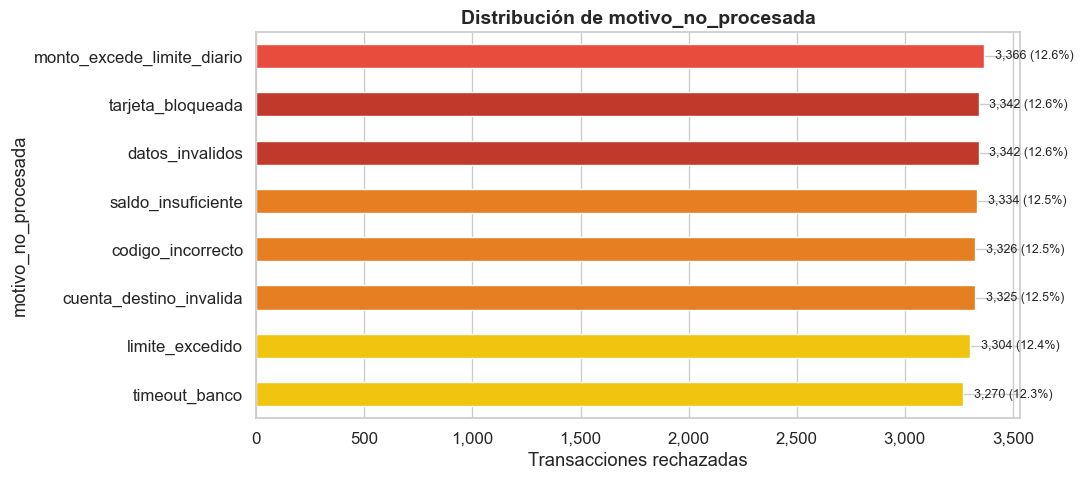

In [5]:
rechazadas = df_tx[df_tx["estatus"] == "no_procesada"].copy()
n_rechazadas = len(rechazadas)

motivos = rechazadas["motivo_no_procesada"].value_counts()
motivos_pct = rechazadas["motivo_no_procesada"].value_counts(normalize=True).mul(100)

pct_saldo = motivos_pct.get("saldo_insuficiente", 0)

print("=" * 60)
print(f"  Total rechazadas: {n_rechazadas:,}")
print("=" * 60)
for motivo, cnt in motivos.items():
    marker = " ◄ PRINCIPAL" if motivo == motivos.index[0] else ""
    print(f"  {motivo:<35}: {cnt:>7,}  ({motivos_pct[motivo]:5.2f}%){marker}")
print("-" * 60)
print(f"  ► % saldo_insuficiente / total rechazos : {pct_saldo:.2f}%")
print(f"  ► % saldo_insuficiente / TOTAL txn      : {n_rechazadas * pct_saldo / 100 / total * 100:.2f}%")

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#e74c3c" if i == 0 else "#c0392b" if i < 3 else "#e67e22" if i < 6 else "#f1c40f"
          for i in range(len(motivos))]
motivos.sort_values().plot(kind="barh", ax=ax, color=colors[::-1])
ax.set_title("Distribución de motivo_no_procesada", fontsize=14, fontweight="bold")
ax.set_xlabel("Transacciones rechazadas")
for bar in ax.patches:
    w = bar.get_width()
    ax.text(w + 50, bar.get_y() + bar.get_height() / 2,
            f"{w:,.0f} ({w/n_rechazadas*100:.1f}%)",
            va="center", fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## 5. Heatmap temporal: `hora_del_dia` × `dia_semana`

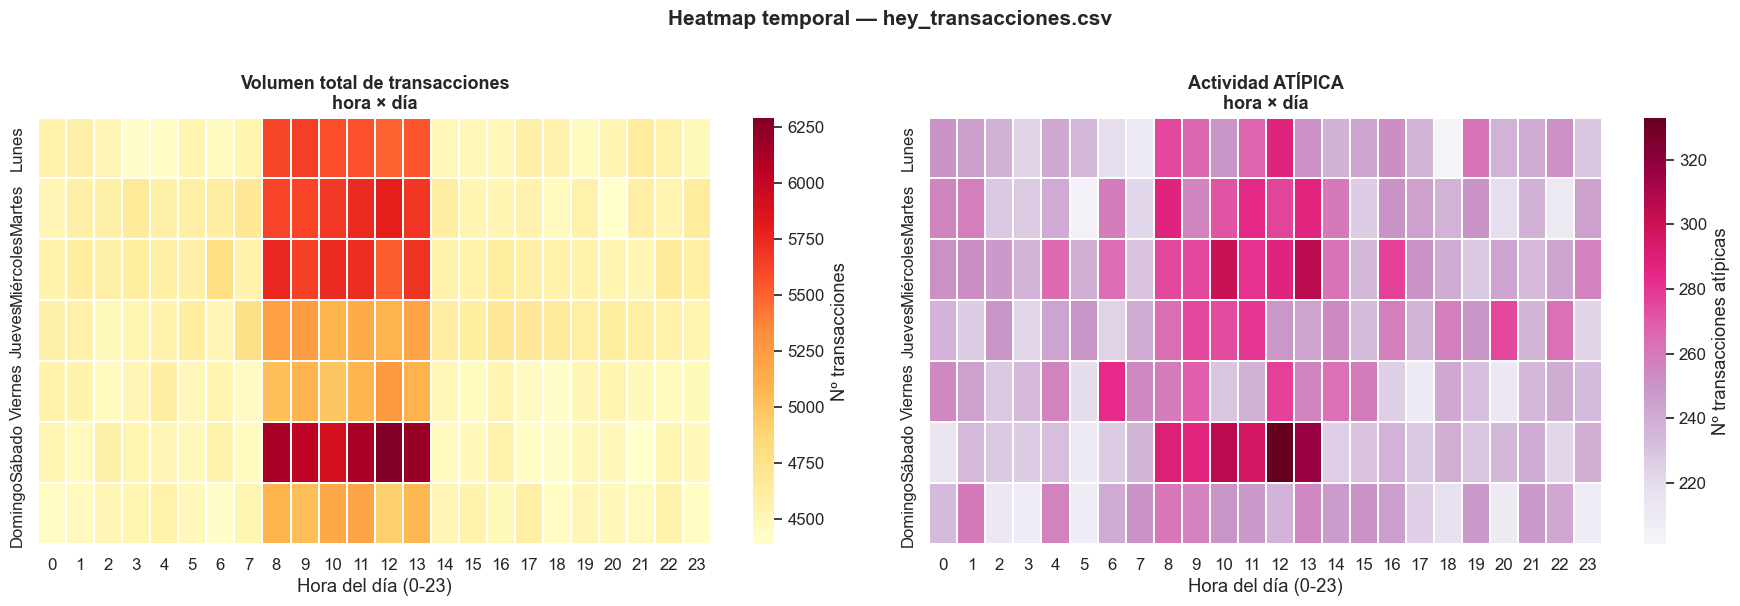


📊 Top 3 horas con mayor VOLUMEN TOTAL:
   11:00 → 38,579 transacciones
   13:00 → 38,482 transacciones
   08:00 → 38,469 transacciones

⚠️  Top 3 horas con mayor ACTIVIDAD ATÍPICA:
   12:00 → 1,948 transacciones atípicas
   13:00 → 1,917 transacciones atípicas
   08:00 → 1,912 transacciones atípicas


In [6]:
DIAS_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
DIAS_ES    = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

heat_all = (
    df_tx.groupby(["dia_semana", "hora_del_dia"])
    .size()
    .unstack(fill_value=0)
    .reindex(DIAS_ORDER)
)
heat_all.index = DIAS_ES

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Heatmap total ─────────────────────────────────────────────────────────────
sns.heatmap(
    heat_all, ax=axes[0], cmap="YlOrRd",
    fmt=",.0f", annot=False, linewidths=0.3,
    cbar_kws={"label": "Nº transacciones"},
)
axes[0].set_title("Volumen total de transacciones\nhora × día", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Hora del día (0-23)")
axes[0].set_ylabel("")

# ── Heatmap actividad atípica ─────────────────────────────────────────────────
heat_atip = (
    df_tx[df_tx["patron_uso_atipico"] == True]
    .groupby(["dia_semana", "hora_del_dia"])
    .size()
    .unstack(fill_value=0)
    .reindex(DIAS_ORDER)
)
heat_atip.index = DIAS_ES

sns.heatmap(
    heat_atip, ax=axes[1], cmap="PuRd",
    fmt=",.0f", annot=False, linewidths=0.3,
    cbar_kws={"label": "Nº transacciones atípicas"},
)
axes[1].set_title("Actividad ATÍPICA\nhora × día", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Hora del día (0-23)")
axes[1].set_ylabel("")

plt.suptitle("Heatmap temporal — hey_transacciones.csv", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Resumen horas pico ────────────────────────────────────────────────────────
horas_total = df_tx.groupby("hora_del_dia").size()
top3_horas  = horas_total.nlargest(3)
horas_atip  = df_tx[df_tx["patron_uso_atipico"] == True].groupby("hora_del_dia").size()
top3_atip   = horas_atip.nlargest(3)

print("\n📊 Top 3 horas con mayor VOLUMEN TOTAL:")
for h, v in top3_horas.items():
    print(f"   {h:02d}:00 → {v:,} transacciones")

print("\n⚠️  Top 3 horas con mayor ACTIVIDAD ATÍPICA:")
for h, v in top3_atip.items():
    print(f"   {h:02d}:00 → {v:,} transacciones atípicas")

## 6. Señales de riesgo: `es_internacional` y `patron_uso_atipico`

  es_internacional = True  :   40,015  (4.99%)
  patron_uso_atipico = True:   41,492  (5.17%)

Transacciones internacionales por tipo_operacion:
tipo_operacion
compra               15876
transf_salida         4653
transf_entrada        4603
cargo_recurrente      3284
pago_credito          2543
pago_servicio         2434
abono_inversion       2054
retiro_cajero         1944
deposito_oxxo         1155
cashback               717
retiro_inversion       594
deposito_farmacia      158


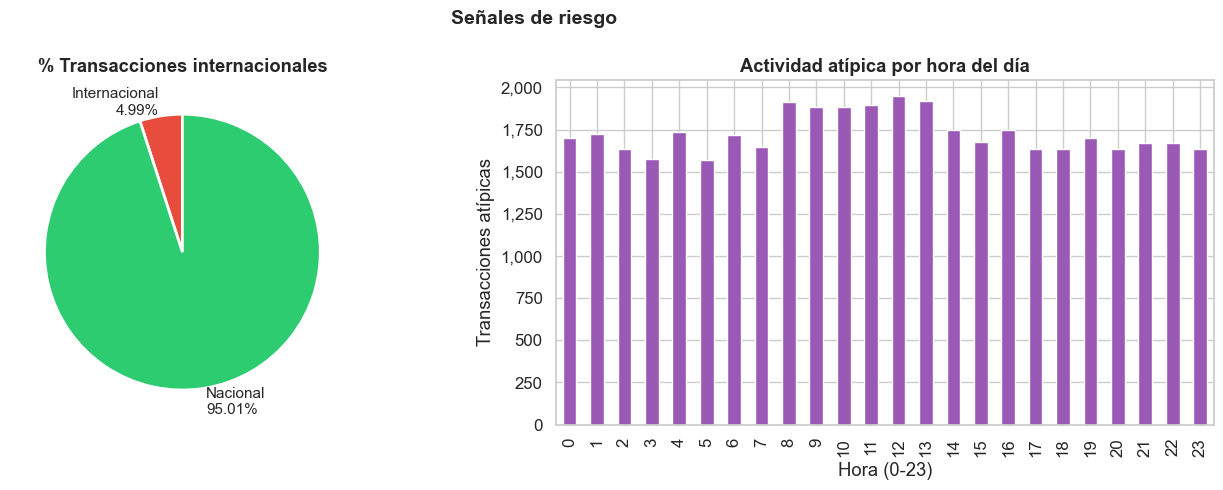

In [7]:
n_intl   = df_tx["es_internacional"].sum()
pct_intl = n_intl / total * 100

n_atip   = df_tx["patron_uso_atipico"].sum()
pct_atip = n_atip / total * 100

print("=" * 55)
print(f"  es_internacional = True  : {n_intl:>8,}  ({pct_intl:.2f}%)")
print(f"  patron_uso_atipico = True: {n_atip:>8,}  ({pct_atip:.2f}%)")
print("=" * 55)

# ── Distribución internacional por tipo_operacion ─────────────────────────────
intl_por_op = (
    df_tx[df_tx["es_internacional"] == True]
    .groupby("tipo_operacion")
    .size()
    .sort_values(ascending=False)
)
print("\nTransacciones internacionales por tipo_operacion:")
print(intl_por_op.to_string())

# ── Atípicas: hora pico ────────────────────────────────────────────────────────
atip_hora = df_tx[df_tx["patron_uso_atipico"] == True].groupby("hora_del_dia").size()

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Pie internacional
axes[0].pie(
    [n_intl, total - n_intl],
    labels=[f"Internacional\n{pct_intl:.2f}%", f"Nacional\n{100-pct_intl:.2f}%"],
    colors=["#e74c3c", "#2ecc71"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11},
)
axes[0].set_title("% Transacciones internacionales", fontweight="bold")

# Actividad atípica por hora
atip_hora.plot(kind="bar", ax=axes[1], color="#9b59b6")
axes[1].set_title("Actividad atípica por hora del día", fontweight="bold")
axes[1].set_xlabel("Hora (0-23)")
axes[1].set_ylabel("Transacciones atípicas")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle("Señales de riesgo", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Cashback — solo usuarios Hey Pro

  Transacciones con cashback: 180,638
  Cashback total generado   : $2,670,791.57 MXN
  Cashback promedio         : $14.79 MXN
  Cashback mediana          : $6.93 MXN
  Cashback máximo           : $764.29 MXN
  Cashback p95              : $49.16 MXN


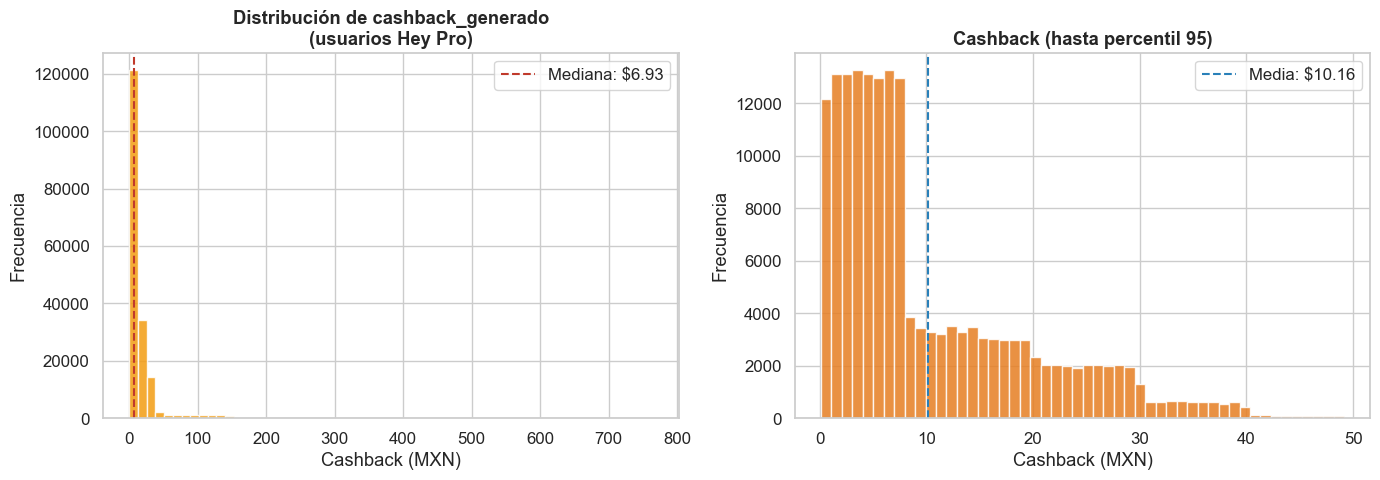

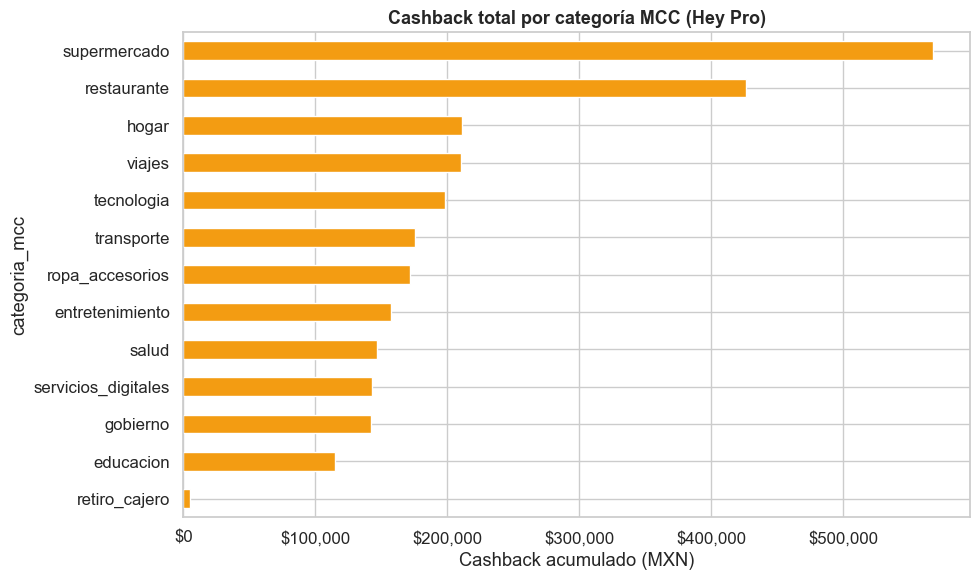

In [8]:
cb = df_tx[
    (df_tx["es_hey_pro"] == True) &
    (df_tx["cashback_generado"].notna()) &
    (df_tx["cashback_generado"] > 0)
]["cashback_generado"]

print("=" * 55)
print(f"  Transacciones con cashback: {len(cb):,}")
print(f"  Cashback total generado   : ${cb.sum():,.2f} MXN")
print(f"  Cashback promedio         : ${cb.mean():,.2f} MXN")
print(f"  Cashback mediana          : ${cb.median():,.2f} MXN")
print(f"  Cashback máximo           : ${cb.max():,.2f} MXN")
print(f"  Cashback p95              : ${cb.quantile(0.95):,.2f} MXN")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Histograma completo
axes[0].hist(cb, bins=60, color="#f39c12", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribución de cashback_generado\n(usuarios Hey Pro)", fontweight="bold")
axes[0].set_xlabel("Cashback (MXN)")
axes[0].set_ylabel("Frecuencia")
axes[0].axvline(cb.median(), color="#c0392b", linestyle="--", linewidth=1.5,
                label=f"Mediana: ${cb.median():,.2f}")
axes[0].legend()

# Histograma recortado en p95 (para ver la masa central)
cb_clip = cb[cb <= cb.quantile(0.95)]
axes[1].hist(cb_clip, bins=50, color="#e67e22", edgecolor="white", alpha=0.85)
axes[1].set_title("Cashback (hasta percentil 95)", fontweight="bold")
axes[1].set_xlabel("Cashback (MXN)")
axes[1].set_ylabel("Frecuencia")
axes[1].axvline(cb_clip.mean(), color="#2980b9", linestyle="--", linewidth=1.5,
                label=f"Media: ${cb_clip.mean():,.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# Cashback por categoria MCC
cb_mcc = (
    df_tx[
        (df_tx["es_hey_pro"] == True) &
        (df_tx["cashback_generado"].notna())
    ].groupby("categoria_mcc")["cashback_generado"]
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
cb_mcc.plot(kind="barh", ax=ax, color="#f39c12")
ax.set_title("Cashback total por categoría MCC (Hey Pro)", fontsize=13, fontweight="bold")
ax.set_xlabel("Cashback acumulado (MXN)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## 8. Top canales por volumen

,n_txn,monto_total,monto_promedio,tasa_rechazo,pct_txn
canal,,,,,
app_ios,"268,313","$1,828,207,251","$6,813.71",3.29%,33.44%
app_android,"226,431","$1,543,534,485","$6,816.80",3.20%,28.22%
pos_fisico,"110,411","$452,453,386","$4,097.90",3.09%,13.76%
app_huawei,"105,577","$767,115,759","$7,265.94",3.41%,13.16%
cajero_banregio,"26,526","$64,548,000","$2,433.39",3.80%,3.31%
codi,"26,354","$145,381,541","$5,516.49",3.26%,3.28%
oxxo,"23,152","$61,282,200","$2,646.95",3.87%,2.89%
cajero_externo,"12,463","$30,259,000","$2,427.91",3.75%,1.55%
farmacia_ahorro,"3,157","$8,577,800","$2,717.07",8.96%,0.39%


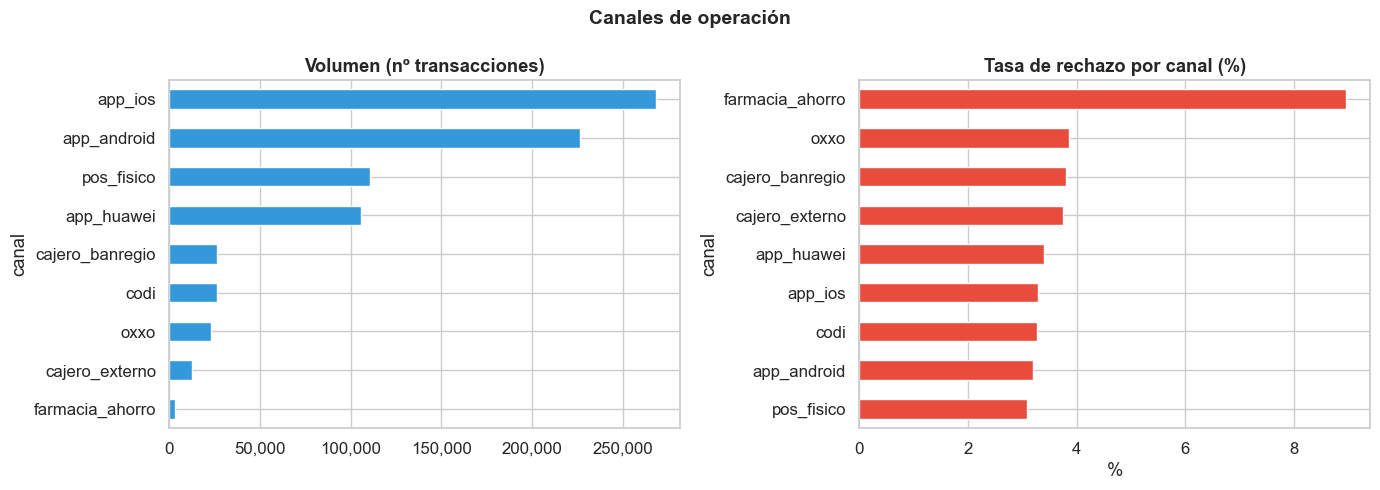

In [9]:
canales = (
    df_tx.groupby("canal")
    .agg(
        n_txn=("transaccion_id", "count"),
        monto_total=("monto", "sum"),
        monto_promedio=("monto", "mean"),
        tasa_rechazo=("estatus",
                      lambda s: (s == "no_procesada").mean() * 100),
    )
    .sort_values("n_txn", ascending=False)
)
canales["pct_txn"] = canales["n_txn"] / total * 100

display(
    canales.style.format({
        "n_txn": "{:,}",
        "monto_total": "${:,.0f}",
        "monto_promedio": "${:,.2f}",
        "tasa_rechazo": "{:.2f}%",
        "pct_txn": "{:.2f}%",
    }).bar(subset=["n_txn"], color="#3498db")
)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

canales["n_txn"].sort_values().plot(kind="barh", ax=axes[0], color="#3498db")
axes[0].set_title("Volumen (nº transacciones)", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

canales["tasa_rechazo"].sort_values().plot(kind="barh", ax=axes[1], color="#e74c3c")
axes[1].set_title("Tasa de rechazo por canal (%)", fontweight="bold")
axes[1].set_xlabel("%")

plt.suptitle("Canales de operación", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Análisis de reintentos (`intento_numero > 1`)

  Transacciones con reintento (intento_numero > 1): 17,720 (2.21%)

Distribución por intento_numero:
intento_numero
1    784664
2      8913
3      8807

Estatus de las transacciones con reintentos:
estatus
no_procesada    17720

Reintentos por tipo_operacion:


,n_reintentos,pct_exitoso
tipo_operacion,,
compra,"6,892",0.0%
transf_entrada,"1,917",0.0%
transf_salida,"1,908",0.0%
pago_credito,"1,622",0.0%
cargo_recurrente,"1,464",0.0%
pago_servicio,"1,036",0.0%
retiro_cajero,995,0.0%
abono_inversion,677,0.0%
deposito_oxxo,587,0.0%


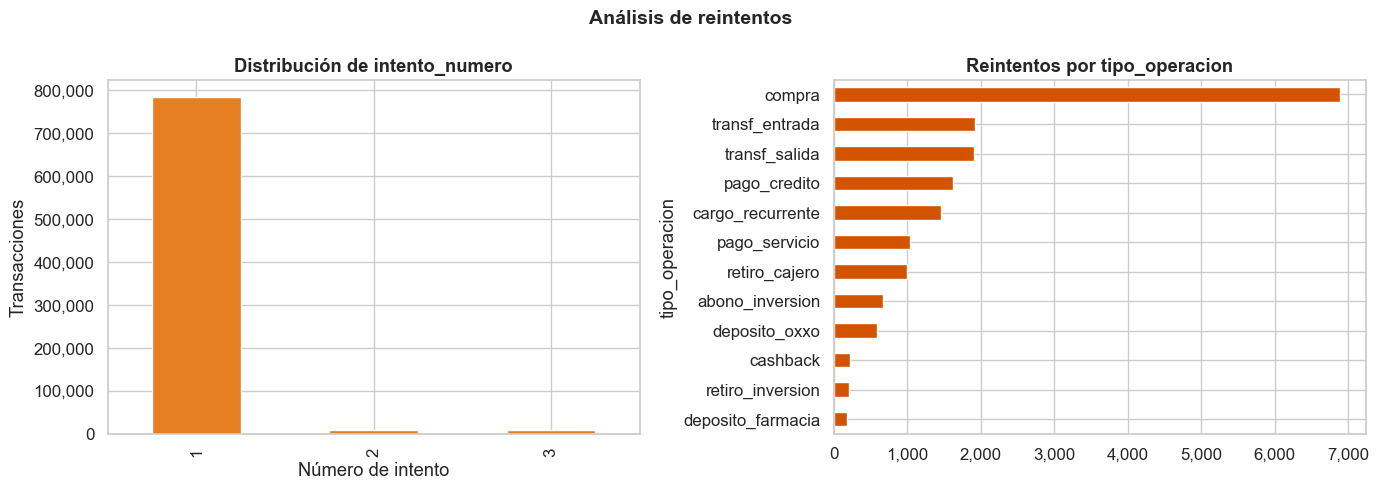

In [10]:
reintentos = df_tx[df_tx["intento_numero"] > 1].copy()
n_reintentos = len(reintentos)
pct_reintentos = n_reintentos / total * 100

print("=" * 60)
print(f"  Transacciones con reintento (intento_numero > 1): {n_reintentos:,} ({pct_reintentos:.2f}%)")
print("=" * 60)

# Distribución del número de intento
print("\nDistribución por intento_numero:")
print(df_tx["intento_numero"].value_counts().sort_index().to_string())

# ¿Qué porcentaje de reintentos termina en éxito?
print("\nEstatus de las transacciones con reintentos:")
print(reintentos["estatus"].value_counts().to_string())

# Por tipo_operacion
reint_op = (
    reintentos.groupby("tipo_operacion")
    .agg(
        n_reintentos=("transaccion_id", "count"),
        pct_exitoso=("estatus",
                     lambda s: (s == "completada").mean() * 100)
    )
    .sort_values("n_reintentos", ascending=False)
)
print("\nReintentos por tipo_operacion:")
display(
    reint_op.style.format({"n_reintentos": "{:,}", "pct_exitoso": "{:.1f}%"})
    .bar(subset=["n_reintentos"], color="#e67e22")
)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

df_tx["intento_numero"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#e67e22", edgecolor="white"
)
axes[0].set_title("Distribución de intento_numero", fontweight="bold")
axes[0].set_xlabel("Número de intento")
axes[0].set_ylabel("Transacciones")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

reint_op["n_reintentos"].sort_values().plot(
    kind="barh", ax=axes[1], color="#d35400"
)
axes[1].set_title("Reintentos por tipo_operacion", fontweight="bold")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle("Análisis de reintentos", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Resumen ejecutivo de KPIs

In [11]:
# ── Calcular todos los KPIs en un solo bloque de cierre ───────────────────────
estatus_vc     = df_tx["estatus"].value_counts()
estatus_pct_kp = df_tx["estatus"].value_counts(normalize=True).mul(100)
n_np           = estatus_vc.get("no_procesada", 0)

motivos_kp     = df_tx[df_tx["estatus"]=="no_procesada"]["motivo_no_procesada"].value_counts()
motivos_pct_kp = df_tx[df_tx["estatus"]=="no_procesada"]["motivo_no_procesada"].value_counts(normalize=True).mul(100)
pct_saldo_kp   = motivos_pct_kp.get("saldo_insuficiente", 0)

n_intl_kp      = df_tx["es_internacional"].sum()
n_atip_kp      = df_tx["patron_uso_atipico"].sum()

cb_total_kp    = df_tx[df_tx["cashback_generado"].notna()]["cashback_generado"].sum()

n_reint_kp     = (df_tx["intento_numero"] > 1).sum()

top_canal      = df_tx["canal"].value_counts().index[0]
top_mcc_kp     = (
    df_tx[df_tx["estatus"]=="completada"]
    .groupby("categoria_mcc")["monto"].sum()
    .idxmax()
)

kpis = pd.DataFrame([
    {"KPI": "Total transacciones",              "Valor": f"{total:,}"},
    {"KPI": "Tasa de rechazo global",           "Valor": f"{estatus_pct_kp.get('no_procesada',0):.2f}%"},
    {"KPI": "% saldo_insuficiente / rechazos",  "Valor": f"{pct_saldo_kp:.2f}%"},
    {"KPI": "% es_internacional",               "Valor": f"{n_intl_kp/total*100:.2f}%"},
    {"KPI": "% patron_uso_atipico",             "Valor": f"{n_atip_kp/total*100:.2f}%"},
    {"KPI": "Cashback total generado",          "Valor": f"${cb_total_kp:,.0f} MXN"},
    {"KPI": "Canal con mayor volumen",          "Valor": top_canal},
    {"KPI": "Categoría MCC top (monto)",        "Valor": top_mcc_kp},
    {"KPI": "Transacciones con reintento",      "Valor": f"{n_reint_kp:,} ({n_reint_kp/total*100:.2f}%)"},
    {"KPI": "Motivo rechazo más frecuente",     "Valor": motivos_kp.index[0] if len(motivos_kp) > 0 else "N/A"},
])

print("\n" + "=" * 55)
print("  RESUMEN EJECUTIVO — hey_transacciones.csv")
print("=" * 55)
for _, row in kpis.iterrows():
    print(f"  {row['KPI']:<40}: {row['Valor']}")
print("=" * 55)


  RESUMEN EJECUTIVO — hey_transacciones.csv
  Total transacciones                     : 802,384
  Tasa de rechazo global                  : 3.32%
  % saldo_insuficiente / rechazos         : 12.53%
  % es_internacional                      : 4.99%
  % patron_uso_atipico                    : 5.17%
  Cashback total generado                 : $2,670,792 MXN
  Canal con mayor volumen                 : app_ios
  Categoría MCC top (monto)               : transferencia
  Transacciones con reintento             : 17,720 (2.21%)
  Motivo rechazo más frecuente            : monto_excede_limite_diario
